Author(s) : Daniel R., Tarry, Laura Gómez Navarro, Elisabet Verger-Miralles

Objective: Describe xxx

Created on: October 2023

Last updated on:


In [1]:
import time

print(time.ctime(time.time()))

Mon Jul 15 01:44:49 2024


In [2]:
import sys
sys.path.insert(0, "../../processing/")

In [3]:
import numpy as np
import xarray as xr # version 0.20.1 necesarry, 0.16 gives error when calculating u_for
import matplotlib.pyplot as plt
import scipy.signal as signal

import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

from read_data_tools import latlon2uv_dir

In [4]:
# version_information

In [5]:
print(xr.__version__)

2023.6.0


# Parameters:

In [6]:
url_drifter = "drifter_svpb035-scb_svpb035/L0/2023/dep0001_drifter-svpb035_scb-svpb035_L0_2023-02-20.nc?"

# --> not used because L0 SOCIB give problems, so L0 downloaded directly from NOAA site (see gdocs)
drifter_type = 'S' # C: CARTHE ; H: Hereon ; S: SVP-B 
# n_window = 12 # we leave like this for now

In [7]:
savedir_figs = '../proc_figures/'

# SVP example

# 1. Loading the data:

In [8]:
# Main root
url_root = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/"

In [9]:
# parameters of the thredd file

if drifter_type == 'C':
    url_vars = "trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]"
    temp_res = 600. # Specifying seconds 
    # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
elif drifter_type == 'H':
    url_vars = "trajectory,time[0:1:-1],LAT[0:1:-1],LON[0:1:-1],DEPTH,PLAT_SPEED_GR[0:1:-1],PLAT_COURSE[0:1:-1],BAT_STATUS[0:1:-1]"
    temp_res = 600. # Specifying seconds 
    # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
elif drifter_type == 'S':
    url_vars = "trajectory,time[0:1:-1],DEPTH,WTEM[0:1:-1],VOLT[0:1:-1],LAT[0:1:-1],DROGUE[0:1:-1],LON[0:1:-1],APRE[0:1:-1]"
    temp_res = 3600.
else:
    print('Something else')
    fsdfs

In [10]:
# Load file

# URL
url = url_root + url_drifter + url_vars
print(url)

if drifter_type == 'S':
    # For SVP-B drifters we cannot use SOCIB L0, so we work offline.  We use the URL to get WMO
    # code, and load the dowloaded L0s from the local folder.
    ds_url = xr.open_dataset(url)
    
    # print(ds_url.trajectory.values)
    # b'drifter-svpb040_scb-svpb040_L0'

    # Local file:
    filedir = '../../../../../data/drifters/L0/SVP-B/'
    fname = 'OSMC_flattened_' + ds_url.wmo_code + '.nc' 
    #'OSMC_flattened_b1df_6660_d879_6102812.nc' --> more than 6h cut-off

    ds00_a = xr.open_dataset(filedir + fname)

    # Rename variables (for coherence with the other drifters)
    ds00_b = ds00_a.rename({'longitude': 'LON', 'latitude': 'LAT'})
    
    ds00 = ds00_b.to_dataframe().set_index(['time']).to_xarray()
    # print(ds00)

elif (drifter_type == 'C') | (drifter_type == 'H'):
    ds00 = xr.open_dataset(url)
else:
    print('drifter_type param. problem')
    sdgsg


http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_svpb035-scb_svpb035/L0/2023/dep0001_drifter-svpb035_scb-svpb035_L0_2023-02-20.nc?trajectory,time[0:1:-1],DEPTH,WTEM[0:1:-1],VOLT[0:1:-1],LAT[0:1:-1],DROGUE[0:1:-1],LON[0:1:-1],APRE[0:1:-1]


In [11]:
ds00

<xarray.Dataset>
Dimensions:        (time: 6242)
Coordinates:
  * time           (time) datetime64[ns] 2023-02-23T18:00:00 ... 2023-11-25
Data variables:
    platform_code  (time) object '6102812' '6102812' ... '6102812' '6102812'
    country        (time) object 'UNKNOWN' 'UNKNOWN' ... 'UNITED STATES'
    LAT            (time) float64 39.38 39.38 39.38 39.38 ... 37.0 37.01 37.01
    LON            (time) float64 2.027 2.028 2.029 2.03 ... 8.852 8.875 8.88
    sst            (time) float64 14.63 14.67 14.66 14.62 ... 20.55 20.13 18.13
    slp            (time) float64 1.009e+03 1.009e+03 ... 1.005e+03 1.005e+03

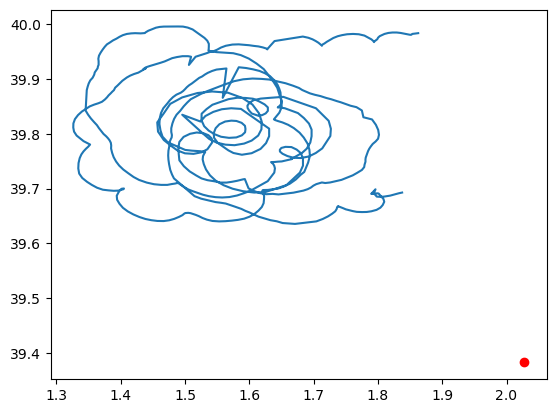

In [56]:
plt.plot(ds00.LON[940:1610], ds00.LAT[940:1610])
plt.scatter(ds00.LON[0], ds00.LAT[0], c='r')

In [57]:
ds00.time[940]

<xarray.DataArray 'time' ()>
array('2023-04-07T09:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2023-04-07T09:00:00

In [59]:
ds00.time[1610]

<xarray.DataArray 'time' ()>
array('2023-05-08T04:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2023-05-08T04:00:00